In [5]:
import numpy as np
from concurrent.futures import ProcessPoolExecutor
from tqdm import tqdm
import pandas as pd
from utils import *
import pandas as pd
import os
new_data = np.linspace(0, 1, 1000) 
seed = 42
args = {"max_leaf_nodes": 5}

####### Simulation parameters  
n_sim = 1000
n = 500
B = 500                                                #  <--------- number of bootstrap samples
folder_name = f"figure2_wager_weighted_boot_samples_500"     # <--------- folder name for results
weighted_boot_samples = True
ij_variance_calc = True
ij_w_variance_calc = False

In [6]:
# sim preparation

n_pred = new_data.shape[0]
####### sim description ############################
text = f"Setting wie in Figure 2 von Wager mit n={n}, B={B}, seed={seed}, max_leaf_nodes={args['max_leaf_nodes']}, n_pred={n_pred} und {n_sim} Simulationen. \n und ungewichtete boot-samples\n"


def make_folder(text,folder_name):
    folder_name2 = folder_name
    if not os.path.exists("./results/" + folder_name2):
        os.makedirs("./results/" + folder_name2)
    with open("./results/" + folder_name2 + "/readme.txt", "w") as f:
        f.write(text)
        
make_folder(text,folder_name)

# data and weights for X
rng = np.random.default_rng(seed)
weights = np.zeros(n)
weights += 1 / int(n/2)
index_drop = rng.choice(range(n), size=int(n/2), replace=False)
weights[index_drop] = 0.0

if weighted_boot_samples:
    boot_weights = weights.copy()
else:
    boot_weights = None


In [7]:
# run sim and save results
with ProcessPoolExecutor() as executor:
    
    bagged_preds = np.zeros((n_sim, new_data.shape[0]))
    biased_var_estimates = np.zeros((n_sim, new_data.shape[0]))
    bias_corrections = np.zeros((n_sim, new_data.shape[0]))
    
    futures = [
        executor.submit(
            simulate_bagging_and_variance,
                n = n,
                B = B,
                new_data = new_data,
                simulation_index = i,
                seed = seed,
                dt_args = args,
                boot_weights = boot_weights,            # <--------- ungewichtete boot-samples erzeugen = None
                ij_variance_calc = ij_variance_calc,
                ij_w_variance_calc = ij_w_variance_calc,
        )
        for i in range(n_sim)
    ]

    for i, future in enumerate(tqdm(futures, desc="Simulations", unit="simulation")):
        bagged_prediction, biased_var_estimate, bias_correction = future.result()
        bagged_preds[i, :] = bagged_prediction
        biased_var_estimates[i, :] = biased_var_estimate
        bias_corrections[i, :] = bias_correction

# save results
np.save(f"./results/{folder_name}/bagged_preds.npy", bagged_preds)
np.save(f"./results/{folder_name}/biased_var_estimates.npy", biased_var_estimates)
np.save(f"./results/{folder_name}/bias_var_corrections.npy", bias_corrections)


Simulations: 100%|██████████| 1000/1000 [00:37<00:00, 26.34simulation/s]


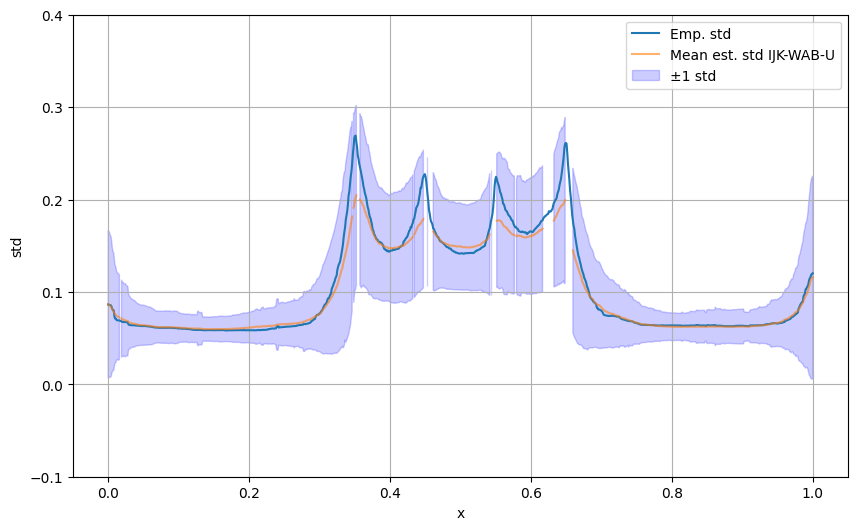

In [8]:
# laden der Ergebnisse
bagged_preds = np.load(f"./results/{folder_name}/bagged_preds.npy")
biased_var_estimates = np.load(f"./results/{folder_name}/biased_var_estimates.npy")
bias_corrections = np.load(f"./results/{folder_name}/bias_var_corrections.npy")

save_results_png(
    new_data=new_data,
    bagged_preds=bagged_preds,
    est_vars_biased=biased_var_estimates,
    bias_correction=bias_corrections,
    folder_name=folder_name,
    n_data_points=n,
    B=B,
    seed=seed,
    dt_args=args,
    m=int(n/2),
    y_lim=[-0.1,0.4]
)
